# **Norwegian News Articles**
Project for TDT4310

By: Malin Haugland Høli

## Topics Modeling per Source

### *Imports*

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import os
import shutil
import gc
from bertopic import BERTopic
from sklearn.metrics.pairwise import cosine_similarity
from sentence_transformers import SentenceTransformer

c:\NTNU\V26\TDT4310\Project\exploring-norwegian-news-sources\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### *Load dataset*

In [3]:
sampled_data = pd.read_parquet("../topic_modeling_bert_sample.parquet")
sampled_data.head(3)

,file,url,source,date,author,gender,class1,class2,language,title,ingress,text,word_count,sentence_count,embeddings
0,AP-20190616-usa-vurderer-alle-mu.xml,http://www.aftenposten.no/verden/i/WbJ4Ej/USA-...,AP,2019-06-16 21:04,Sigurd Bjørnestad,Male,verden,"internasjonal politikk,amerikansk politikk,mik...",Bokmål,«USA vurderer alle muligheter» mot Iran,Utenriksminister Mike Pompeo sier et militært ...,– Selvsagt. Selvsagt.\nSlik svarte utenriksmin...,312,23,"[-0.049493045, -0.5488504, -0.3132547, -0.0561..."
1,DB-20190105-dattera-til-drillo-j.xml,http://www.dagbladet.no/kjendis/dattera-til-dr...,DB,2019-01-05 10:00,"Linn-Christin Marthinussen, John Terje Pederse...",Female,kjendis,"datteren til drillo,mesternes mester 2019,chee...",Bokmål,Dattera til Drillo: - Jeg spyttet på Sir Alex ...,For «Mesternes mester»-aktuelle Kine Olsen Ved...,MALLORCA (Dagbladet): - Jeg føler egentlig hel...,1078,84,"[-0.08203984, -0.14517953, 0.10554722, 0.30175..."
2,VG-20190221-kristine-stavas-skis.xml,http://www.vg.no/sport/langrenn/i/8wy6Ew/krist...,VG,2019-02-21 14:29,"Herman Tinius Folvik, Camilla Vesteng, Jens Fr...",Male,"sport,langrenn",None,Bokmål,Kristine Stavås Skistad ut i tårer etter fall ...,SEEFELD (VG) Kristine Stavås Skistad (20) så u...,– Det er bare utrolig kjipt. Jeg ramler fra fi...,317,29,"[-0.5379853, -0.36339787, -0.95606214, 0.24945..."


In [4]:
print(sampled_data.columns)
print(f"Unique sources: {sampled_data['source'].nunique()}")

Index(['file', 'url', 'source', 'date', 'author', 'gender', 'class1', 'class2',
       'language', 'title', 'ingress', 'text', 'word_count', 'sentence_count',
       'embeddings'],
      dtype='str')
Unique sources: 10


### *Group sampled data by source*

In [5]:
grouped_by_source = sampled_data.groupby("source")
for source, group in grouped_by_source:
    print(f"Source: {source}, Number of articles: {len(group)}")

Source: AA, Number of articles: 3137
Source: AP, Number of articles: 12117
Source: BT, Number of articles: 2354
Source: DA, Number of articles: 4587
Source: DB, Number of articles: 9996
Source: DN, Number of articles: 4178
Source: FV, Number of articles: 1084
Source: NL, Number of articles: 2275
Source: SA, Number of articles: 6273
Source: VG, Number of articles: 3999


In [6]:
data_by_source = {source: {"texts": group["text"].tolist(), "embeddings": group["embeddings"].tolist()} for source, group in grouped_by_source}

### *Load model*

In [7]:
model_name = "NbAiLab/nb-sbert-base"
embedding_model = SentenceTransformer(model_name, trust_remote_code=True)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6791.37it/s]
BertModel LOAD REPORT from: NbAiLab/nb-sbert-base
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


### *Export BERTopic topic statistics and per-topic keyword summaries*

In [8]:
def add_topics_data(topic_model, n_texts, topics, save_path):
    topic_series = pd.Series(topics)
    topic_counts = topic_series.value_counts()

    num_topics = len(topic_counts) - (1 if -1 in topic_counts.index else 0)
    noise_count = topic_counts.get(-1, 0)
    avg_topic_size = topic_counts[topic_counts.index != -1].mean() if num_topics > 0 else 0

    # save number of topics, noise count, and average topic size to a text file
    with open(f"{save_path}/topic_model_stats.txt", "w") as f:
        f.write(f"Number of documents in sample: {n_texts}\n")
        f.write(f"Number of documents classified as noise: {noise_count}\n")
        f.write(f"Percentage of documents classified as noise: {noise_count / (n_texts + noise_count):.2%}\n")
        f.write(f"Number of topics (excluding noise): {num_topics}\n")
        f.write(f"Average number of documents per topic (excluding noise): {avg_topic_size:.2f}\n")


def save_topic_info(topic_model, save_path, topics: list[int]):
    topic_counts = pd.Series(topics).value_counts().to_dict()
    del topic_counts[-1] # remove noise topic

    # Write top 10 topics with keywords and their counts to a text file
    with open(f"{save_path}/top_topics.txt", "w") as f:
        for topic_id, count in topic_counts.items():
            keywords = topic_model.get_topic(topic_id)
            # Format keyword and score
            keywords_with_scores = [f"{kw} ({score:.3f})" for kw, score in keywords]
            f.write(f"Topic {topic_id} (Count: {count}): {keywords_with_scores}\n")

### *Project documents from each source into a shared topic space*

In [9]:
# Clean up memory before loading the model
gc.collect()

# Load the pre-trained BERTopic model with the specified embedding model
topic_model = BERTopic.load("../bertopic_models/NbAiLab_nb-sbert-base/NbAiLab_nb-sbert-base_ngram1-3_n50000_min_df10_20260409_201329"
                            , embedding_model=embedding_model)

for source, data in data_by_source.items():
    print(f"Processing source: {source}")
    texts = data["texts"]
    embeddings = data["embeddings"]
    embeddings = np.array(embeddings)
    
    topics, probs = topic_model.transform(texts, embeddings)

    save_path = f"../bertopic_models/sources_experiment_base_model/bertopic_{source}"
    shutil.rmtree(save_path, ignore_errors=True) # remove existing directory if it exists
    os.makedirs(save_path, exist_ok=True)

    add_topics_data(topic_model, len(texts), topics, save_path)
    save_topic_info(topic_model, save_path, topics)

    # Clean up memory
    del texts, embeddings, topics, probs
    gc.collect()

2026-04-18 23:50:40,877 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Processing source: AA


2026-04-18 23:50:41,153 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Processing source: AP


2026-04-18 23:50:41,438 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


...

Processing source: NL


2026-04-18 23:50:43,031 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Processing source: SA


2026-04-18 23:50:43,297 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.


Processing source: VG


### *Print top 10 topic distribution from each source*

In [10]:
# compare topics across sources by loading top topics from each source
data_dir = "../bertopic_models/sources_experiment_base_model"
sources = ["AP", "DB", "AA", "DN", "BT", "DA", "FV", "NL", "SA", "VG"]
topics_dict = {}

for source in sources:
    with open(f"{data_dir}/bertopic_{source}/top_topics.txt", "r") as f:
        topics_dict[source] = f.read().splitlines()

for source, topics in topics_dict.items():
    print(f"Top 10 topics for {source}:")
    for topic in topics[:10]:
        print(topic)
    print()


Top 10 topics for AP:
Topic 0 (Count: 3298): ['scoret (0.451)', 'league (0.428)', 'spillerne (0.428)', 'spillere (0.403)', 'champions (0.377)', 'ballen (0.373)', 'kamper (0.359)', 'manchester (0.356)', 'laget (0.349)', 'sesong (0.348)']
Topic 2 (Count: 1510): ['pågrepet (0.378)', 'etterforskningen (0.342)', 'drept (0.316)', 'døde (0.315)', 'fornærmede (0.314)', 'politidistrikt (0.282)', 'politiets (0.275)', 'politiet (0.265)', 'elisabeth (0.252)', 'død (0.243)']
Topic 1 (Count: 1248): ['brexit (0.588)', 'parlamentet (0.366)', 'statsministeren (0.337)', 'statsminister (0.316)', 'stortinget (0.292)', 'regjering (0.275)', 'valget (0.272)', 'regjeringen (0.272)', 'valg (0.271)', 'avtalen (0.233)']
Topic 4 (Count: 812): ['årets (0.376)', 'serien (0.369)', 'tv (0.311)', 'kjent (0.300)', 'åringen (0.285)', 'på (0.262)', 'gang (0.260)', 'filmen (0.248)', 'fjor (0.246)', 'film (0.244)']
Topic 3 (Count: 763): ['ulykken (0.525)', 'nødetatene (0.477)', 'politiet på (0.444)', 'operasjonsleder (0.42

### *Compare sources based on topics*

In [11]:
all_source_topics = []
all_sources = []

In [12]:
for source, data in data_by_source.items():    
    texts = data["texts"]
    embeddings = np.array(data["embeddings"])

    topics, probs = topic_model.transform(texts, embeddings)

    all_source_topics.extend(topics)
    all_sources.extend([source] * len(topics))

2026-04-18 23:53:30,575 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-04-18 23:53:30,608 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-04-18 23:53:30,662 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-04-18 23:53:30,686 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-04-18 23:53:30,702 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-04-18 23:53:30,739 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-04-18 23:53:30,753 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embeddings.
2026-04-18 23:53:30,770 - BERTopic - Predicting topic assignments through cosine similarity of topic and document embe

In [13]:
df = pd.DataFrame({
    "source": all_sources,
    "topic": all_source_topics
})

In [14]:
topic_dist = pd.crosstab(df["source"], df["topic"])
topic_dist_norm = topic_dist.div(topic_dist.sum(axis=1), axis=0)

### *Similarity Matrix of news sources based on the topics found from BERTopic*

In [15]:
sim_matrix = cosine_similarity(topic_dist_norm)
sim_df = pd.DataFrame(sim_matrix, index=topic_dist_norm.index, columns=topic_dist_norm.index)
print(sim_df.to_string())

source        AA        AP        BT        DA        DB        DN        FV        NL        SA        VG
source                                                                                                    
AA      1.000000  0.876543  0.902405  0.658043  0.808621  0.154623  0.880112  0.489819  0.883734  0.802890
AP      0.876543  1.000000  0.978644  0.889535  0.969906  0.339921  0.973437  0.413345  0.976406  0.965259
BT      0.902405  0.978644  1.000000  0.871855  0.932491  0.332116  0.976911  0.492225  0.950409  0.931655
DA      0.658043  0.889535  0.871855  1.000000  0.882331  0.538119  0.854369  0.490185  0.842549  0.883008
DB      0.808621  0.969906  0.932491  0.882331  1.000000  0.358157  0.942434  0.386051  0.945250  0.990426
DN      0.154623  0.339921  0.332116  0.538119  0.358157  1.000000  0.423066  0.313619  0.311932  0.305296
FV      0.880112  0.973437  0.976911  0.854369  0.942434  0.423066  1.000000  0.435808  0.960705  0.924367
NL      0.489819  0.413345  0.492225 

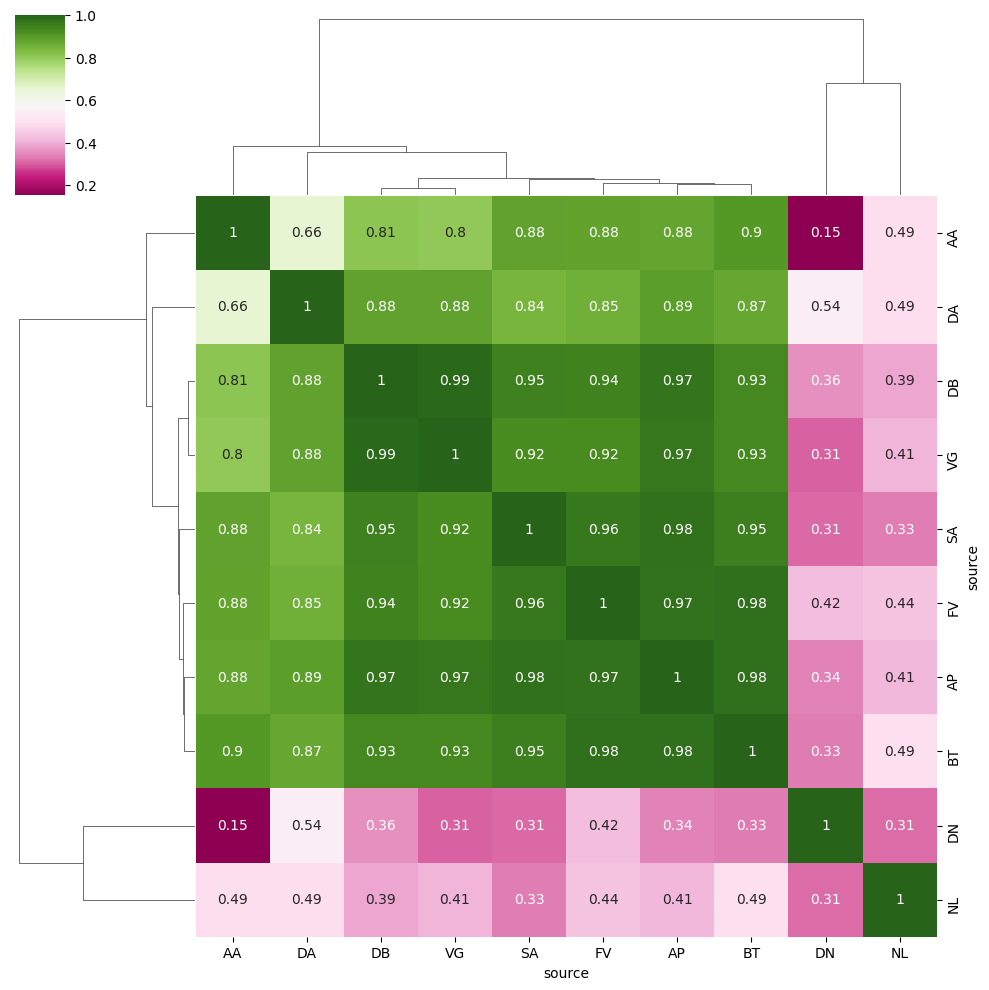

In [16]:
sns.clustermap(
    sim_df,
    cmap="PiYG",
    annot=True,
    figsize=(10, 10)
)

plt.show()

### *Why is DN noticeably different from the rest of the news sources?*

In [17]:
mainstream = topic_dist_norm.drop("DN").mean()
dn = topic_dist_norm.loc["DN"]

diff = dn - mainstream

top_dn_topics = diff.sort_values(ascending=False).head(10)
least_dn_topics = diff.sort_values().head(10)
key_words = {topic_id: topic_model.get_topic(topic_id) for topic_id in set(top_dn_topics.index).union(set(least_dn_topics.index))}

# print top topics and their keywords for DN compared to mainstream
print("Top 10 topics more prevalent in DN compared to mainstream:")
for topic_id in top_dn_topics.index:
    print(f"Topic {topic_id}: {key_words[topic_id]}")
print("\nTop 10 topics less prevalent in DN compared to mainstream:")
for topic_id in least_dn_topics.index:
    print(f"Topic {topic_id}: {key_words[topic_id]}")

Top 10 topics more prevalent in DN compared to mainstream:
Topic 6: [['milliarder kroner', 0.4151332378387451], ['millioner kroner', 0.3955841064453125], ['kvartal', 0.38710883259773254], ['økte', 0.3719973862171173], ['veksten', 0.3478155732154846], ['milliarder', 0.3422679007053375], ['prisene', 0.33575698733329773], ['fjor', 0.332946240901947], ['vekst', 0.32644620537757874], ['utviklingen', 0.3137717545032501]]
Topic 5: [['president donald trump', 0.5027315616607666], ['presidentens', 0.49688851833343506], ['sa trump', 0.4729771614074707], ['presidenten', 0.47129732370376587], ['usas president', 0.46118485927581787], ['donald trump', 0.4554929733276367], ['president donald', 0.4515061378479004], ['trump', 0.42886149883270264], ['president', 0.40507644414901733], ['trumps', 0.380691260099411]]
Topic 1: [['brexit', 0.58842533826828], ['parlamentet', 0.3663708567619324], ['statsministeren', 0.3374108672142029], ['statsminister', 0.31552189588546753], ['stortinget', 0.2915959358215332]